In [66]:
!wget -O isimler.txt https://raw.githubusercontent.com/ozymaxx/turkce_dil_verisi/master/tum_isimler.txt
# !wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt


--2026-09-05 00:18:15--  https://raw.githubusercontent.com/ozymaxx/turkce_dil_verisi/master/tum_isimler.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 100199 (98K) [text/plain]
Saving to: ‘isimler.txt’

isimler.txt         100%[===================>]  97.85K  --.-KB/s    in 0.03s   

2026-09-05 00:18:15 (3.67 MB/s) - ‘isimler.txt’ saved [100199/100199]



In [67]:
rows = open('isimler.txt', 'r').read().splitlines()

In [68]:
#data cleaning
words = []
for r in rows:
  isim = r.replace('İ', 'i').replace('I','ı')
  isim = isim.lower()
  isim = isim.strip()
  isim = isim.replace('.', '')
  isim = isim.replace('â', 'a').replace('î', 'i').replace('û', 'u')
  isim = isim.replace('˜', 'i').replace('š', 'ü').replace('¦', 'ğ')
  if len(isim) >= 2 and 'w' not in isim and 'x' not in isim and 'q' not in isim:
    words.append(isim)


In [70]:
[w for w in words if ' ' in w][:10]

[]

In [71]:
[w for w in words if '.' in w][:10]

[]

In [72]:
[w for w in words if 'w' in w][:10]

[]

In [73]:
[w for w in words if '.' in w]

[]

In [74]:
[w for w in words if 'š' in w or '˜' in w or '¦' in w]

[]

In [69]:
#alphabet
len(words)
words
sorted(list(set(''.join(words))))

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'r',
 's',
 't',
 'u',
 'v',
 'y',
 'z',
 'ç',
 'ö',
 'ü',
 'ğ',
 'ı',
 'ş']

In [75]:
b = {}
for w in words:
  chs = ['<S>'] + list(w) + ['<E>']
  for ch1, ch2 in zip(chs, chs[1:]):
    bigram = (ch1,ch2)
    b[bigram] = b.get(bigram,0) +1

In [76]:
sorted(b.items() , key = lambda  kv : -kv[1])

[(('n', '<E>'), 2872),
 (('a', 'n'), 2211),
 (('e', 'r'), 1670),
 (('<S>', 'a'), 1584),
 (('r', '<E>'), 1461),
 (('e', '<E>'), 1326),
 (('a', 'y'), 1215),
 (('a', 'l'), 1118),
 (('g', 'ü'), 979),
 (('l', '<E>'), 966),
 (('<S>', 'm'), 942),
 (('<S>', 'b'), 939),
 (('e', 'n'), 936),
 (('i', 'n'), 925),
 (('h', 'a'), 908),
 (('<S>', 'g'), 891),
 (('a', '<E>'), 863),
 (('a', 'r'), 863),
 (('u', 'r'), 809),
 (('<S>', 's'), 807),
 (('k', 'a'), 768),
 (('r', 'a'), 755),
 (('ü', 'l'), 750),
 (('t', '<E>'), 744),
 (('m', 'e'), 744),
 (('<S>', 'e'), 743),
 (('<S>', 'n'), 736),
 (('<S>', 't'), 734),
 (('n', 'a'), 696),
 (('<S>', 'k'), 691),
 (('k', '<E>'), 680),
 (('y', '<E>'), 678),
 (('t', 'a'), 670),
 (('s', 'e'), 659),
 (('b', 'a'), 648),
 (('b', 'e'), 626),
 (('n', 'e'), 620),
 (('l', 'a'), 617),
 (('i', '<E>'), 616),
 (('a', 'k'), 603),
 (('e', 'l'), 589),
 (('i', 'l'), 584),
 (('s', 'a'), 582),
 (('a', 't'), 578),
 (('<S>', 'h'), 573),
 (('d', 'e'), 535),
 (('d', 'i'), 514),
 (('r', 'e'), 

In [77]:
import torch

In [78]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [79]:
N = torch.zeros ((30,30) , dtype = torch.int32)

In [97]:
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1 , ix2] += 1

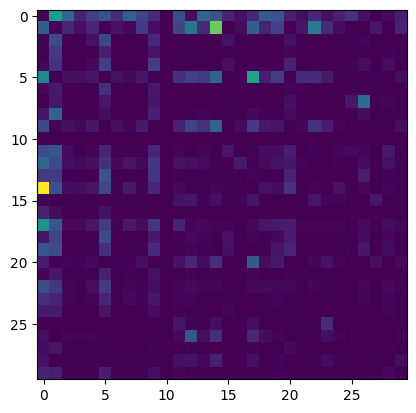

In [81]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

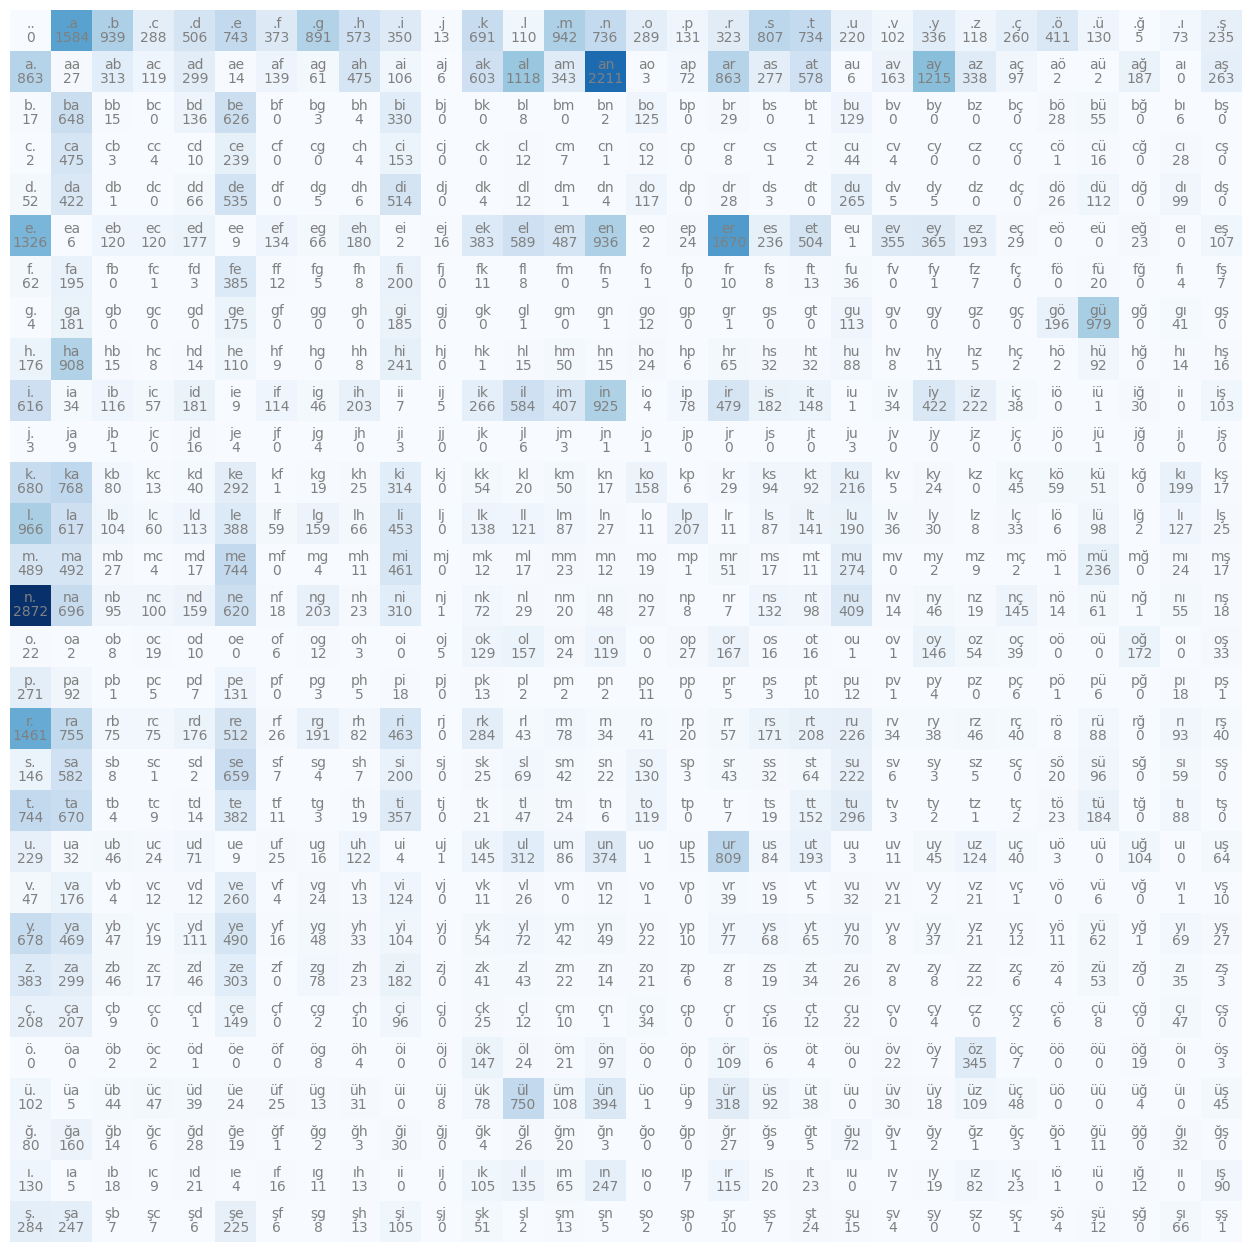

In [82]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(30):
    for j in range(30):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [83]:
#Görev_2#

In [84]:
N[0 , :]

tensor([   0, 1584,  939,  288,  506,  743,  373,  891,  573,  350,   13,  691,
         110,  942,  736,  289,  131,  323,  807,  734,  220,  102,  336,  118,
         260,  411,  130,    5,   73,  235], dtype=torch.int32)

In [85]:
p = N[0].float()
p = p/p.sum()
p

tensor([0.0000, 0.1227, 0.0727, 0.0223, 0.0392, 0.0575, 0.0289, 0.0690, 0.0444,
        0.0271, 0.0010, 0.0535, 0.0085, 0.0729, 0.0570, 0.0224, 0.0101, 0.0250,
        0.0625, 0.0568, 0.0170, 0.0079, 0.0260, 0.0091, 0.0201, 0.0318, 0.0101,
        0.0004, 0.0057, 0.0182])

In [86]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p , num_samples=1 , replacement=True, generator=g).item()
itos[ix]


'g'

In [87]:
P = (N+1).float()
P /= P.sum(1, keepdims=True)

In [88]:
g = torch.Generator().manual_seed(2147483647)

for i in range(3):
  out = []
  ix = 0
  while True:
    p = P[ix]
    #p = N[ix].float()
    #p = p / p.sum()
    ix = torch.multinomial(p , num_samples=1 , replacement=True , generator=g).item()
    out.append(itos[ix])
    if ix == 0:
     break
  print(''.join(out))

güsran.
merslbi.
te.


In [89]:
log_likelihood = 0.0
n = 0.0

for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P [ix1 , ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
 #  print(f'{ch1}{ch2} : {prob:.4f} {logprob : .4f}')
print(f'{log_likelihood}')
nll = -log_likelihood
print(f'{nll/n}')

-231310.546875
2.495743989944458


In [90]:
# Creating Training Set of Bigrams (x,y)
xs , ys = [] , []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()


In [91]:
xs #inputs

tensor([ 0,  1,  2,  ..., 29,  4,  9])

In [92]:
ys #real subsequent letters coming from real names based on inputs.

tensor([1, 2, 1,  ..., 4, 9, 0])

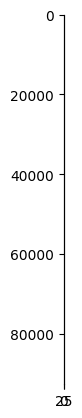

In [96]:
import torch.nn.functional as F #one-hot
xenc = F.one_hot(xs , num_classes=30).float()
plt.imshow(xenc)

In [94]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((30,30), requires_grad=True )

for k in range(100):
  ## Forward Pass
  xenc = F.one_hot(xs , num_classes=30).float()
  logits = xenc @ W # log-counts
  counts = (xenc @ W).exp() # behaves like N-tensor
  ######################
  probs = counts / counts.sum(1, keepdim=True)
  loss = -probs[(torch.arange(num),ys)].log().mean() + 0.01 * (W**2).mean()

  W.grad = None
  loss.backward()

  W.data += -10 * W.grad
  print(loss)


tensor(3.8153, grad_fn=<AddBackward0>)
tensor(3.7461, grad_fn=<AddBackward0>)
tensor(3.6822, grad_fn=<AddBackward0>)
tensor(3.6230, grad_fn=<AddBackward0>)
tensor(3.5682, grad_fn=<AddBackward0>)
tensor(3.5174, grad_fn=<AddBackward0>)
tensor(3.4706, grad_fn=<AddBackward0>)
tensor(3.4275, grad_fn=<AddBackward0>)
tensor(3.3879, grad_fn=<AddBackward0>)
tensor(3.3515, grad_fn=<AddBackward0>)
tensor(3.3182, grad_fn=<AddBackward0>)
tensor(3.2876, grad_fn=<AddBackward0>)
tensor(3.2593, grad_fn=<AddBackward0>)
tensor(3.2331, grad_fn=<AddBackward0>)
tensor(3.2087, grad_fn=<AddBackward0>)
tensor(3.1859, grad_fn=<AddBackward0>)
tensor(3.1645, grad_fn=<AddBackward0>)
tensor(3.1443, grad_fn=<AddBackward0>)
tensor(3.1251, grad_fn=<AddBackward0>)
tensor(3.1069, grad_fn=<AddBackward0>)
tensor(3.0896, grad_fn=<AddBackward0>)
tensor(3.0730, grad_fn=<AddBackward0>)
tensor(3.0572, grad_fn=<AddBackward0>)
tensor(3.0421, grad_fn=<AddBackward0>)
tensor(3.0276, grad_fn=<AddBackward0>)
tensor(3.0137, grad_fn=<A

In [95]:
## Sampling

g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  out = []
  ix = 0
  while True:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=30).float()
    logits = xenc @ W
    counts = logits.exp()
    p = counts / counts.sum(1, keepdim=True) ## Broadcasting 'sum(1, keepdim=True)'
    ix = torch.multinomial(p , num_samples=1 , replacement=True , generator=g).item()
    out.append(itos[ix])
    if ix == 0:
     break
  print(''.join(out));


güsran.
merslbi.
te.
öeri.
yhimur.
